# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs and below) 
3. sapphire.run(parameters) 

Soon there will be:
- a way to run from the command line "python -m sapphire parameters.json"-
- repeatedly run internally with built-in HMC/nested sampling functions
- the JAX version ported over for JIT (10x speed boost) and gradients (for both optimization and physical interpretation)

In [1]:
%matplotlib inline
import sys

# Change to wherever sapphire is located
sapphire_dir = '/mnt/home/bterrazas/ceph/sapphire_bhcomb/'
sys.path.insert(0, sapphire_dir+'sapphire')
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck15

import importlib

import sapphire 

import multiprocess
print(multiprocess.cpu_count())

from astropy import units as u
s_to_yr = u.s.to('yr')

importlib.reload(sapphire)

48


<module 'sapphire' from '/mnt/home/bterrazas/ceph/sapphire_bhcomb/sapphire/sapphire/__init__.py'>

In [2]:
""" This is an optional feature we are using to downsample the # of halos we will model to speed up computation time """

# define a list of (Mlow,Mhigh,N) tuples with same bin definitions as Behroozi+19 relation
# we will only model N random halos within each of these z=0 Mvir mass bins to cut down on modeling time
# this list of tuples is an input runtime parameter for sapphire below (along with np.random.seed(#) for reproducibility) 
downsample_bins = np.arange(10.0,14.2,0.2) # note the masses are log10 mvir
print(downsample_bins)

# we will ask for 5 random halos per mass bin
downsample_defs = [(downsample_bins[i],downsample_bins[i+1],5) for i in range(len(downsample_bins)-1)]

downsample_defs

[10.  10.2 10.4 10.6 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6
 12.8 13.  13.2 13.4 13.6 13.8 14. ]


[(10.0, 10.2, 5),
 (10.2, 10.399999999999999, 5),
 (10.399999999999999, 10.599999999999998, 5),
 (10.599999999999998, 10.799999999999997, 5),
 (10.799999999999997, 10.999999999999996, 5),
 (10.999999999999996, 11.199999999999996, 5),
 (11.199999999999996, 11.399999999999995, 5),
 (11.399999999999995, 11.599999999999994, 5),
 (11.599999999999994, 11.799999999999994, 5),
 (11.799999999999994, 11.999999999999993, 5),
 (11.999999999999993, 12.199999999999992, 5),
 (12.199999999999992, 12.399999999999991, 5),
 (12.399999999999991, 12.59999999999999, 5),
 (12.59999999999999, 12.79999999999999, 5),
 (12.79999999999999, 12.99999999999999, 5),
 (12.99999999999999, 13.199999999999989, 5),
 (13.199999999999989, 13.399999999999988, 5),
 (13.399999999999988, 13.599999999999987, 5),
 (13.599999999999987, 13.799999999999986, 5),
 (13.799999999999986, 13.999999999999986, 5)]

In [3]:
# set up a general parameters dict 

# try running new thermal_general model on same 656 TNG trees
parameters = {'output_path':sapphire_dir+'sapphire/output/', # path where any output files should be saved (irrelevant if return_or_write=='return' below)
              
              ### runtime-related related parameters (you only need to vary tree_path) 
              
              'tree_type':'tng_sapphire', # type of merger trees / MAHs -- this determines what read_trees module gets loaded
              'tree_path':sapphire_dir+'sapphire/data/tng_trees_compactified_20subvolumes.npz', # either a directory containing tree files or path to single tree file itself 
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':None, # for testing speed purposes, only work with trees from a single TNG subvolume 
              'num_readers':5, # irrelevant for tree_type='tng_sapphire'
              'num_writers':5, # irrelevant when return_or_write = 'return' (otherwise how many output writer tasks to start in parallel)
              'return_or_write':'return', # if 'return', return pandas dataframe (you should assign to a variable below); if 'write' then save dataframe to hdf5
              'min_root_mass':1e10, # relevant for tree_type ='tng' and 'tng_sapphire', not 'fire2' or 'fire2_pandya22'
              'max_root_mass':None, # relevant for tree_type=tng_sapphire -- halos above this z=0 Mvir will not be modeled (set to None or 0 to model everything)
              'downsample_defs':downsample_defs, # list of tuples (logMlow,logMhigh,N) such that N random halos will be chosen in each mass bin (None otherwise)
              'downsample_seed':999, # np.random.seed(#) to ensure reproducibility when downsampling to N random halos in each mass bin (None otherwise)
              'rtol':1e-5, # relative error tolerance for ODE solver (this controls error on exponent of state variables), should be 1e-3 or lower 
              'atol':1e-3, # absolute error tolerance for ODE solver (this controls early evolution when ICs close to 0), should be 1e-3 or lower 
              
              ### fixed physical model parameters (this just sets the overall physical model and associated fixed parameters) 
              
              'physical_model':'thermal_general_AGN', # name of physical model (and associated free parameter functional forms)
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm                            
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'return_all':False, # whether to return only the ODE RHS for solver, or all properties at each time for outputting
              
              ### FREE PARAMETERS BELOW THIS LINE -- WE WILL VARY A SUBSET OF THESE 
              ### there are 4 physical parameters: mass, energy and metal loading factors, and the ISM depletion time
              ### each physical parameter has 4 hyperparameters describing a power law: normalization, slope, and the redshift dependences of those two
              ### the exact power law is X(Vvir,z) = A * (Vvir/125.)**(alpha0 + alphaz*(1+z)) * (1+z)**beta              
              
              'etaM_A':0.1, # normalization of power law for mass loading factor [prior range: 0.01 to 100]
              'etaM_alpha0':-0.5, # slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_alphaz':0.0, # this can be fixed to 0; redshift dependence of slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_beta':0.0, # this can be fixed to 0; redshift dependence of normalization of power law for mass loading factor [prior range: -2 to 2]
              'tdep_A':3.0, # [prior range: 0.01 to 10]
              'tdep_alpha0':-3.0, # [prior range: -2 to 2]
              'tdep_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'tdep_beta':-0.7, # [prior range: -2 to 2]
              'etaE_A':0.5, # [prior range: 0.01 to 1]
              'etaE_alpha0':-0.5, # [prior range: -2 to 2]
              'etaE_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaE_beta':0.0,   # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_A':0.5, # [prior range: 0.01 to 1]
              'etaZ_alpha0':0.0, # [prior range: -2 to 2]
              'etaZ_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_beta':0.0,# this can be fixed to 0 [prior range: -2 to 2]
              'f_bh':1.0e-4,
              'kappa_bh':1.0e-3,
              'etaE_BH':0.1} 



In [4]:
tstart = timer()
df_results = sapphire.run(parameters) # this is the only line you need, I just enclosed it in a timer for benchmarking
print('Finished in %s sec'%(timer()-tstart))


Finished in 43.02022754900099 sec


In [5]:
### the results are returned as a pandas dataframe 
# the row index is roothaloid and the columns are different physical properties 
# the entries are the time series of these physical properties for each halo 
df_results

,Mdot_cool,Mbh_dot,MZdot_in_halo,MZdot_ism,Eth_cgm,T0,n0,MZdot_cgm,Edot_out_halo,Zin_halo,...,NFW_vcirc,Ebind_cgm,Edot_wind,Ncoolingshells,f_UV,sol_nfev,sol_njev,sol_nlu,sol_success,sol_status
1123826638,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5.956782559219069e-23, 5.957871709541405e-23,...","[8.054130145108527e-07, 8.096860050649863e-07,...","[44.425591594593264, 38.75779050446463, 34.385...","[6.82338678345211e+50, 2.503414935641316e+51, ...","[49.24712605738829, 179.7930510938508, 312.507...","[0.02011201307640329, 0.020086593354007375, 0....","[5.733482362937297, 5.673076093538767, 5.61446...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7.85391266205108e-06, 7.887170085443401e-06, ...",...,"[30.729868562330665, 30.743296869528688, 30.75...","[3.7334515810312473e+53, 3.7563553102892812e+5...","[5.956782559219067e+30, 5.957871709541404e+30,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.999863140689785, 0.9998574601542979, 0.9998...","[1095.0, 1095.0, 1095.0, 1095.0, 1095.0, 1095....","[66.0, 66.0, 66.0, 66.0, 66.0, 66.0, 66.0, 66....","[230.0, 230.0, 230.0, 230.0, 230.0, 230.0, 230...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1123011124,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.2814876710497063e-22, 1.2805983942979153e-2...","[1.2063279692269925e-06, 1.2114474509743305e-0...","[74.47508622359913, 58.78839960087654, 48.5776...","[1.2024451997329363e+51, 3.9020826617761775e+5...","[55.90413431201586, 180.86007957381076, 309.23...","[0.030619794785214725, 0.030548226981278133, 0...","[4.3105850333590805, 4.277471349387574, 4.2451...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0196190982728364e-05, 1.0235957220791271e-0...",...,"[36.786443032715376, 36.79925149228218, 36.812...","[8.939156627584789e+53, 8.972816487412219e+53,...","[1.2281297735894555e+31, 1.2270656998124409e+3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9999982561577893, 0.9999981747534815, 0.999...","[1121.0, 1121.0, 1121.0, 1121.0, 1121.0, 1121....","[62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62.0, 62....","[191.0, 191.0, 191.0, 191.0, 191.0, 191.0, 191...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124729141,"[0.0, 0.1996181930252034, 0.34258741347582583,...","[4.6530884594348626e-23, 1.461131663282304e-18...","[1.708687847214296e-06, 1.7159688386045067e-06...","[53.565747435332526, 4681.972579602868, 372.40...","[9.691226784451575e+50, 2.3394679724515083e+53...","[48.804629671199535, 11707.505013748567, 11727...","[0.008953991977894529, 0.008955965545091054, 0...","[13.100515789249492, 9.69536904231753, 7.99417...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.1066072609349369e-05, 1.1111572860314323e-0...",...,"[28.89533264485341, 28.914237931367335, 28.933...","[5.193521929083997e+53, 5.233724868717792e+53,...","[4.653088459434862e+30, 1.461131663282304e+35,...","[0, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43...","[0.995551587144687, 0.9955267021372582, 0.9955...","[930.0, 930.0, 930.0, 930.0, 930.0, 930.0, 930...","[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....","[168.0, 168.0, 168.0, 168.0, 168.0, 168.0, 168...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1124728969,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5.282415328941513e-23, 5.2745839398967573e-23...","[1.7750269596192704e-07, 1.7809518378867744e-0...","[34.65147348747572, 30.95636922267027, 27.9796...","[4.926650405526869e+50, 9.065850094122468e+50,...","[47.47916607103118, 87.2219160764944, 126.2538...","[0.025023158842331725, 0.02495102506185692, 0....","[1.4840337843734506, 1.4864566659380982, 1.488...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[6.160327551309261e-06, 6.179781410710592e-06,...",...,"[26.42468961491093, 26.428583523459853, 26.432...","[2.480020827022074e+53, 2.4844951676051503e+53...","[5

In [6]:
# suppose the only thing we cared about was predicting the z=0 SMHM relation for a given set of model parameters

# use list comprehension to store final z=0 Mvir and Mstar of each halo (i.e., of each row aka roothaloid of df_filtered)
# here we are iterating over each row which is a distinct roothaloid
# the values of every column for a given row/roothaloid are numpy arrays of time series of that property going from high-z to z~0

z0_Mvir = np.array([df_results.iloc[irow]['Mvir'][-1] for irow in range(len(df_results))])
z0_Mstar = np.array([df_results.iloc[irow]['M_star'][-1] for irow in range(len(df_results))])
z0_Mbh = np.array([df_results.iloc[irow]['M_BH'][-1] for irow in range(len(df_results))])
z0_Mdotbh = np.array([df_results.iloc[irow]['Mbh_dot'][-1] for irow in range(len(df_results))])

Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

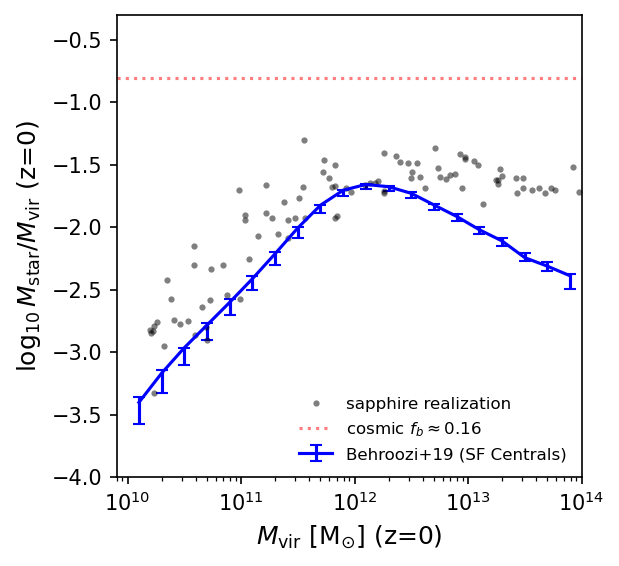

In [7]:
# overplot the z=0 SMHM relation of this model vs the Behroozi SMHM relation for centrals at z=0

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

### plot Behroozi+19 relation including only central SF galaxies/halos
# first read in Behroozi+19 UniverseMachine DR1 Median SMHM relation at z=0  
# and discard bins below logmvir<10.5 due to Bolshoi-Planck resolution limit (not sure why he included these)
tum = Table.read('smhm_a1.002312.dat',format='ascii')
tum = tum[(tum['HM(0)']>=10.0) & (tum['HM(0)']<=14.0)]

ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

# plot our model's realization
ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire realization')

ax.set_xscale('log')
ax.set_xlim(None,1e14)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)


#### You can see that since we don't have AGN yet, the model overpredicts the SMHM relation in massive group/cluster halos
#### Other observable constraints can also be folded in

Text(0, 0.5, 'Mdot_BH [Msun/yr]')

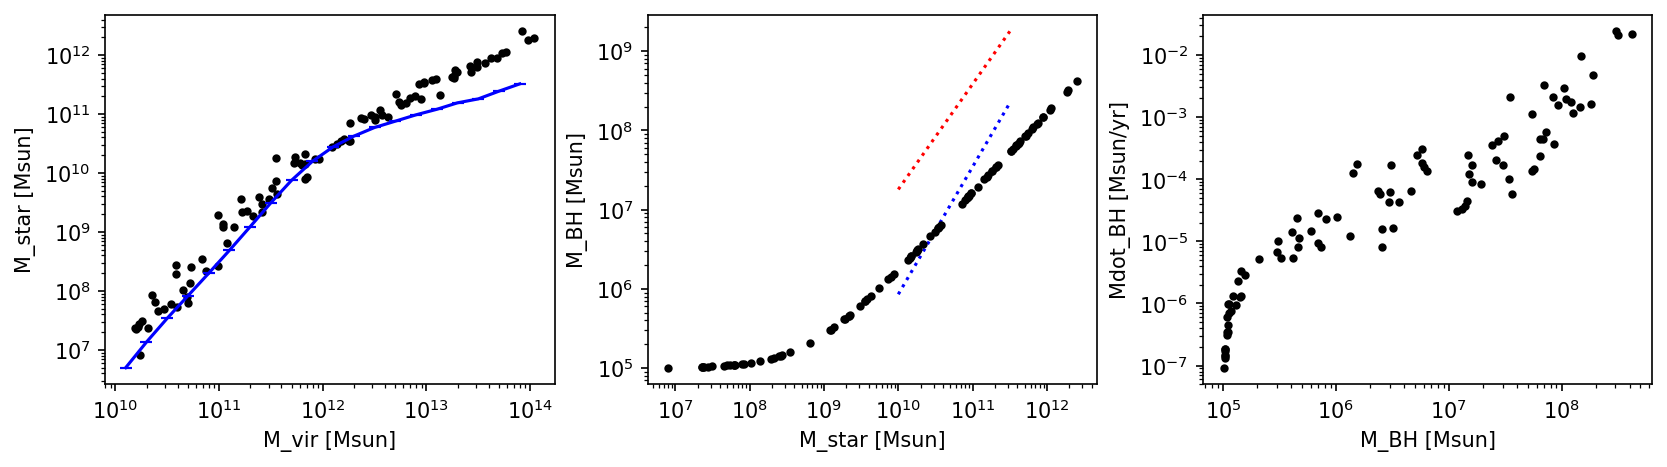

In [8]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),dpi=150,constrained_layout=True)

axes[0].loglog(z0_Mvir,z0_Mstar,'k.')
axes[0].errorbar(10**tum['HM(0)'],10**tum['HM(0)']*10**tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')
axes[0].set_xlabel('M_vir [Msun]')
axes[0].set_ylabel('M_star [Msun]')

sm_array = np.logspace(10,11.5,10)
line_sf = 10**(6.70 + 1.61*np.log10(sm_array/3e10))
line_qu = 10**(7.89 + 1.33*np.log10(sm_array/3e10))
axes[1].loglog(sm_array, line_qu, 'r:', lw=1.5, label='Greene+19')
axes[1].loglog(sm_array, line_sf, 'b:', lw=1.5)
axes[1].loglog(z0_Mstar,z0_Mbh,'k.')
axes[1].set_xlabel('M_star [Msun]')
axes[1].set_ylabel('M_BH [Msun]')

axes[2].loglog(z0_Mbh,z0_Mdotbh/s_to_yr,'k.')
axes[2].set_xlabel('M_BH [Msun]')
axes[2].set_ylabel('Mdot_BH [Msun/yr]')